<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/Probability_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 機械学習に必要な確率統計

## ベイズの定理

In [4]:
import numpy as np

prevalence = 0.01
sensitivity = 0.95
specificity = 0.90

p_positive = sensitivity * prevalence + (1 - specificity) * (1 - prevalence)
p_disease_given_positive = (sensitivity * prevalence) / p_positive

print(f"検査陽性時の疾患確率: {p_disease_given_positive:.4f} ({p_disease_given_positive*100:.1f}%)")


検査陽性時の疾患確率: 0.0876 (8.8%)


## 正規分布

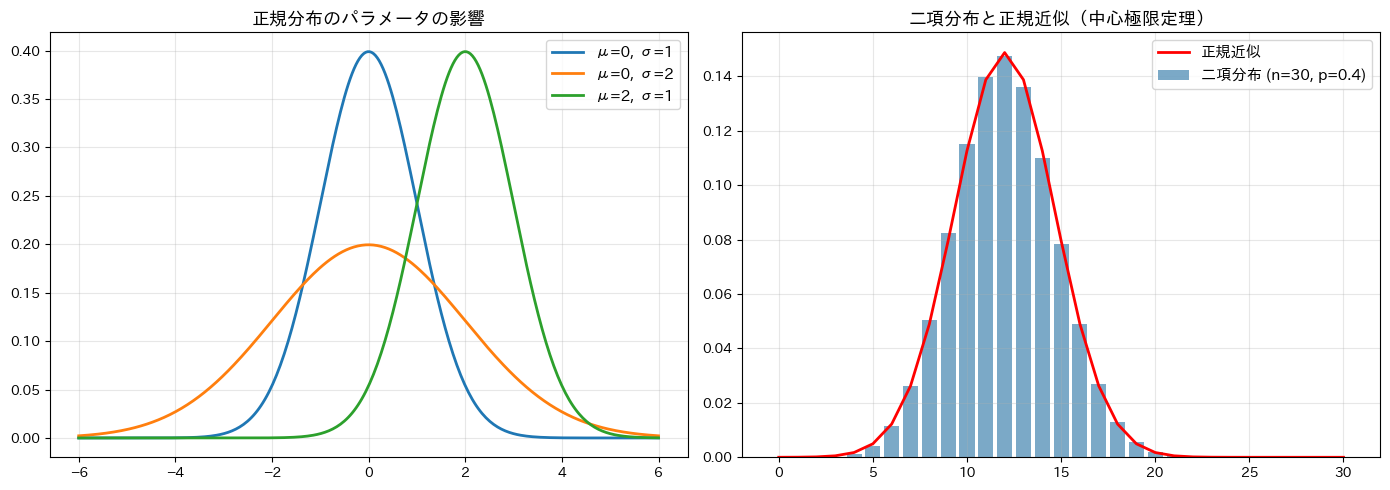

In [5]:
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 正規分布（パラメータ比較）
for mu, sigma, label in [(0, 1, 'μ=0, σ=1'), (0, 2, 'μ=0, σ=2'),
                          (2, 1, 'μ=2, σ=1')]:
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2, label=label)
axes[0].set_title('正規分布のパラメータの影響', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 二項分布 vs 正規近似
n, p = 30, 0.4
k = np.arange(0, n+1)
binom_pmf = stats.binom.pmf(k, n, p)
normal_approx = stats.norm.pdf(k, n*p, np.sqrt(n*p*(1-p)))

axes[1].bar(k, binom_pmf, alpha=0.6, label=f'二項分布 (n={n}, p={p})', color='#2471A3')
axes[1].plot(k, normal_approx, 'r-', linewidth=2, label='正規近似')
axes[1].set_title('二項分布と正規近似（中心極限定理）', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()


## 共分散行列と相関係数

=== 共分散行列 ===
（特徴量: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']）

    0.686   -0.042    1.274    0.516
   -0.042    0.190   -0.330   -0.122
    1.274   -0.330    3.116    1.296
    0.516   -0.122    1.296    0.581

=== 相関行列 ===

    1.000   -0.118    0.872    0.818
   -0.118    1.000   -0.428   -0.366
    0.872   -0.428    1.000    0.963
    0.818   -0.366    0.963    1.000


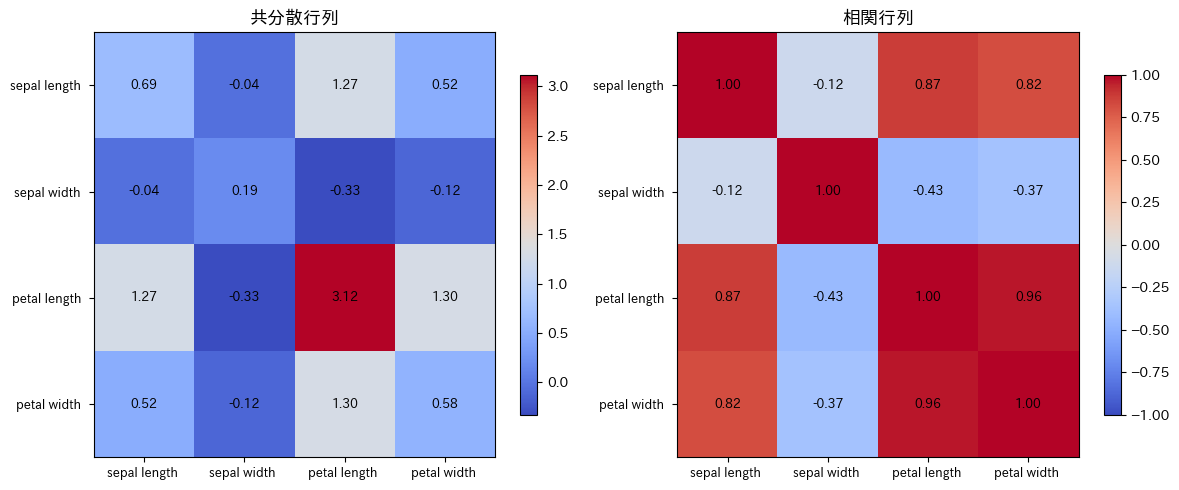

In [9]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# 共分散行列の計算
cov_matrix = np.cov(X, rowvar=False)

# 相関行列の計算
corr_matrix = np.corrcoef(X, rowvar=False)

print("=== 共分散行列 ===")
print(f"（特徴量: {feature_names}）\n")
for i in range(4):
    row = "  ".join(f"{cov_matrix[i,j]:7.3f}" for j in range(4))
    print(f"  {row}")

print("\n=== 相関行列 ===\n")
for i in range(4):
    row = "  ".join(f"{corr_matrix[i,j]:7.3f}" for j in range(4))
    print(f"  {row}")

# ヒートマップで可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(cov_matrix, cmap='coolwarm', aspect='auto')
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels([n.split('(')[0] for n in feature_names], fontsize=9)
axes[0].set_yticklabels([n.split('(')[0] for n in feature_names], fontsize=9)
axes[0].set_title('共分散行列', fontsize=13)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels([n.split('(')[0] for n in feature_names], fontsize=9)
axes[1].set_yticklabels([n.split('(')[0] for n in feature_names], fontsize=9)
axes[1].set_title('相関行列', fontsize=13)
plt.colorbar(im1, ax=axes[1], shrink=0.8)

for ax, mat in [(axes[0], cov_matrix), (axes[1], corr_matrix)]:
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('covariance_correlation.png', dpi=150)
plt.show()


## 正規分布のMLE

=== 正規分布のパラメータ推定 ===

真のパラメータ:     μ = 5.0000, σ² = 4.0000
MLE:               μ = 5.0387, σ² = 3.8316
不偏推定量:         μ = 5.0387, σ² = 3.8355


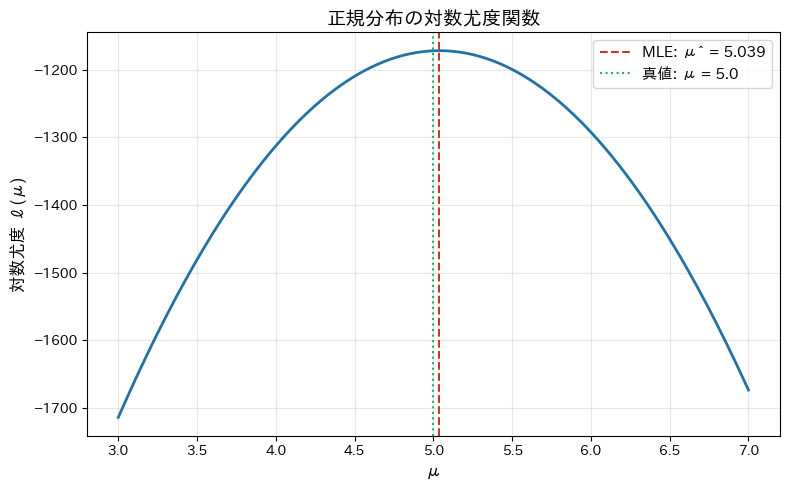

In [13]:
# 正規分布の MLE
np.random.seed(42)
true_mu, true_sigma = 5.0, 2.0
data = np.random.normal(true_mu, true_sigma, size=1000)

mu_mle = np.mean(data)
sigma2_mle = np.var(data)           # MLE（偏りあり: m で割る）
sigma2_unbiased = np.var(data, ddof=1)  # 不偏推定量（m-1 で割る）

print("=== 正規分布のパラメータ推定 ===\n")
print(f"真のパラメータ:     μ = {true_mu:.4f}, σ² = {true_sigma**2:.4f}")
print(f"MLE:               μ = {mu_mle:.4f}, σ² = {sigma2_mle:.4f}")
print(f"不偏推定量:         μ = {mu_mle:.4f}, σ² = {sigma2_unbiased:.4f}")

# 対数尤度の可視化
mu_range = np.linspace(3, 7, 200)
log_likelihoods = [-0.5 * np.sum((data - mu)**2) / sigma2_mle
                   - 0.5 * len(data) * np.log(sigma2_mle)
                   for mu in mu_range]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mu_range, log_likelihoods, linewidth=2, color='#2471A3')
ax.axvline(x=mu_mle, color='#C0392B', linestyle='--', label=f'MLE: μ̂ = {mu_mle:.3f}')
ax.axvline(x=true_mu, color='#27AE60', linestyle=':', label=f'真値: μ = {true_mu}')
ax.set_xlabel('μ', fontsize=12)
ax.set_ylabel('対数尤度 ℓ(μ)', fontsize=12)
ax.set_title('正規分布の対数尤度関数', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('log_likelihood.png', dpi=150)
plt.show()


## コイン投げの例: MLE vs MAP

MLE: p̂ = 1.0000
MAP (Beta(2,2) prior): p̂ = 0.8000


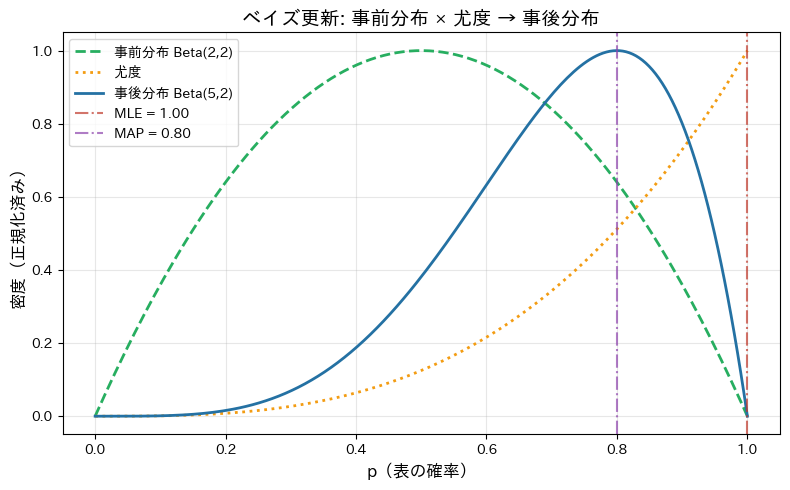

In [14]:
# コイン投げの例: MLE vs MAP
from scipy.stats import beta as beta_dist

# データ: 3回中3回表
n_heads, n_tails = 3, 0
n_total = n_heads + n_tails

# MLE
p_mle = n_heads / n_total
print(f"MLE: p̂ = {p_mle:.4f}")

# MAP（Beta(2,2) 事前分布 = 「偏りのないコインだろう」という弱い事前知識）
alpha_prior, beta_prior = 2, 2
p_map = (n_heads + alpha_prior - 1) / (n_total + alpha_prior + beta_prior - 2)
print(f"MAP (Beta(2,2) prior): p̂ = {p_map:.4f}")

# 事後分布（Beta(α+heads, β+tails)）
alpha_post = alpha_prior + n_heads
beta_post = beta_prior + n_tails

p_range = np.linspace(0, 1, 200)
prior = beta_dist.pdf(p_range, alpha_prior, beta_prior)
likelihood = p_range**n_heads * (1-p_range)**n_tails
posterior = beta_dist.pdf(p_range, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_range, prior / prior.max(), '--', color='#27AE60', linewidth=2, label='事前分布 Beta(2,2)')
ax.plot(p_range, likelihood / likelihood.max(), ':', color='#F39C12', linewidth=2, label='尤度')
ax.plot(p_range, posterior / posterior.max(), '-', color='#2471A3', linewidth=2, label='事後分布 Beta(5,2)')
ax.axvline(x=p_mle, color='#C0392B', linestyle='-.', alpha=0.7, label=f'MLE = {p_mle:.2f}')
ax.axvline(x=p_map, color='#8E44AD', linestyle='-.', alpha=0.7, label=f'MAP = {p_map:.2f}')
ax.set_xlabel('p（表の確率）', fontsize=12)
ax.set_ylabel('密度（正規化済み）', fontsize=12)
ax.set_title('ベイズ更新: 事前分布 × 尤度 → 事後分布', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bayesian_update.png', dpi=150)
plt.show()


## エントロピーと交差エントロピー

In [15]:
# エントロピーと交差エントロピーの計算
def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def cross_entropy(p, q):
    mask = p > 0
    return -np.sum(p[mask] * np.log2(q[mask]))

def kl_divergence(p, q):
    mask = p > 0
    return np.sum(p[mask] * np.log2(p[mask] / q[mask]))

# 例: 3クラスの真の分布と推定された分布
P = np.array([0.7, 0.2, 0.1])      # 真の分布
Q_good = np.array([0.6, 0.25, 0.15])  # 良い推定
Q_bad = np.array([0.1, 0.5, 0.4])     # 悪い推定

print("=== 情報理論の指標 ===\n")
print(f"真の分布 P:      {P}")
print(f"良い推定 Q_good: {Q_good}")
print(f"悪い推定 Q_bad:  {Q_bad}")
print()
print(f"H(P):               {entropy(P):.4f} bits")
print(f"H(P, Q_good):       {cross_entropy(P, Q_good):.4f} bits")
print(f"H(P, Q_bad):        {cross_entropy(P, Q_bad):.4f} bits")
print(f"KL(P || Q_good):    {kl_divergence(P, Q_good):.4f} bits")
print(f"KL(P || Q_bad):     {kl_divergence(P, Q_bad):.4f} bits")


=== 情報理論の指標 ===

真の分布 P:      [0.7 0.2 0.1]
良い推定 Q_good: [0.6  0.25 0.15]
悪い推定 Q_bad:  [0.1 0.5 0.4]

H(P):               1.1568 bits
H(P, Q_good):       1.1896 bits
H(P, Q_bad):        2.6575 bits
KL(P || Q_good):    0.0328 bits
KL(P || Q_bad):     1.5008 bits


## バイアス・バリアンス・トレードオフ

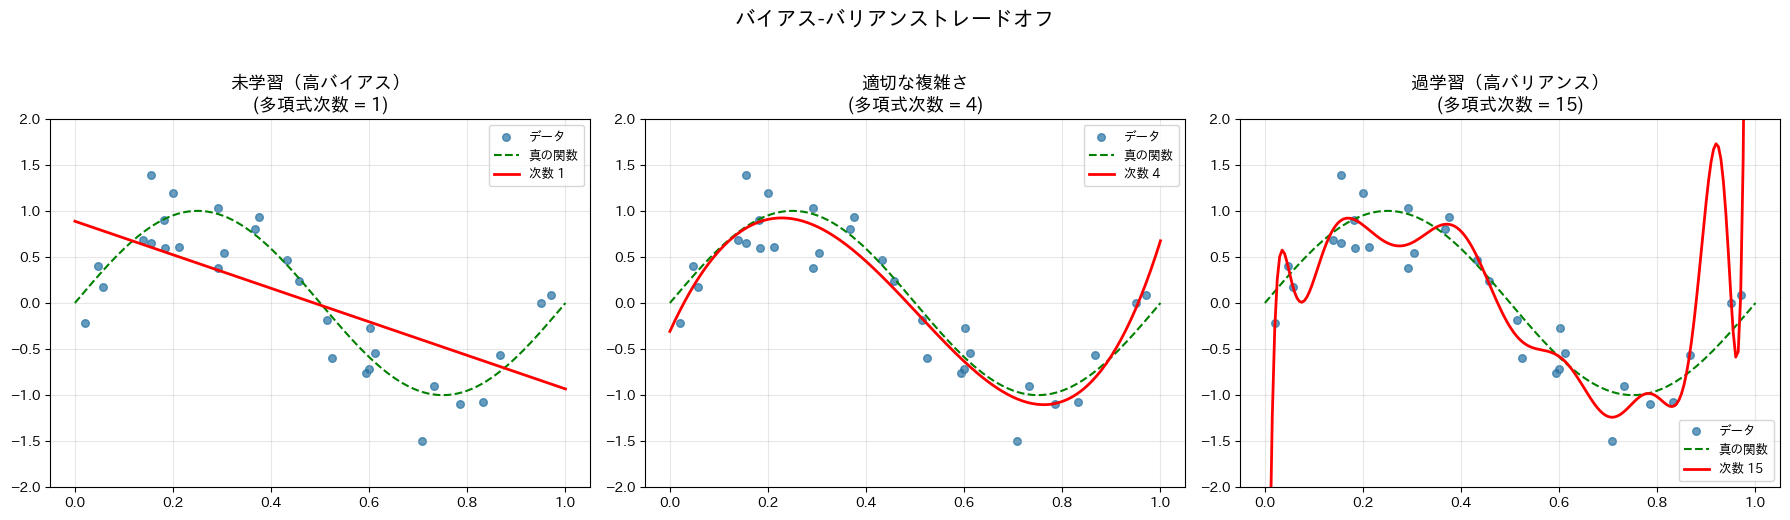

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# 真の関数
def true_function(x):
    return np.sin(2 * np.pi * x)

np.random.seed(42)
n_samples = 30
X = np.sort(np.random.uniform(0, 1, n_samples))
y = true_function(X) + np.random.randn(n_samples) * 0.3

X_plot = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
degrees = [1, 4, 15]
labels = ['未学習（高バイアス）', '適切な複雑さ', '過学習（高バリアンス）']

for ax, degree, label in zip(axes, degrees, labels):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('lr', LinearRegression())
    ])
    model.fit(X.reshape(-1, 1), y)
    y_plot = model.predict(X_plot.reshape(-1, 1))

    ax.scatter(X, y, color='#2471A3', s=30, alpha=0.7, label='データ')
    ax.plot(X_plot, true_function(X_plot), 'g--', linewidth=1.5, label='真の関数')
    ax.plot(X_plot, y_plot, 'r-', linewidth=2, label=f'次数 {degree}')
    ax.set_title(f'{label}\n(多項式次数 = {degree})', fontsize=13)
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('バイアス-バリアンストレードオフ', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('bias_variance.png', dpi=150)
plt.show()


## 中心極限定理

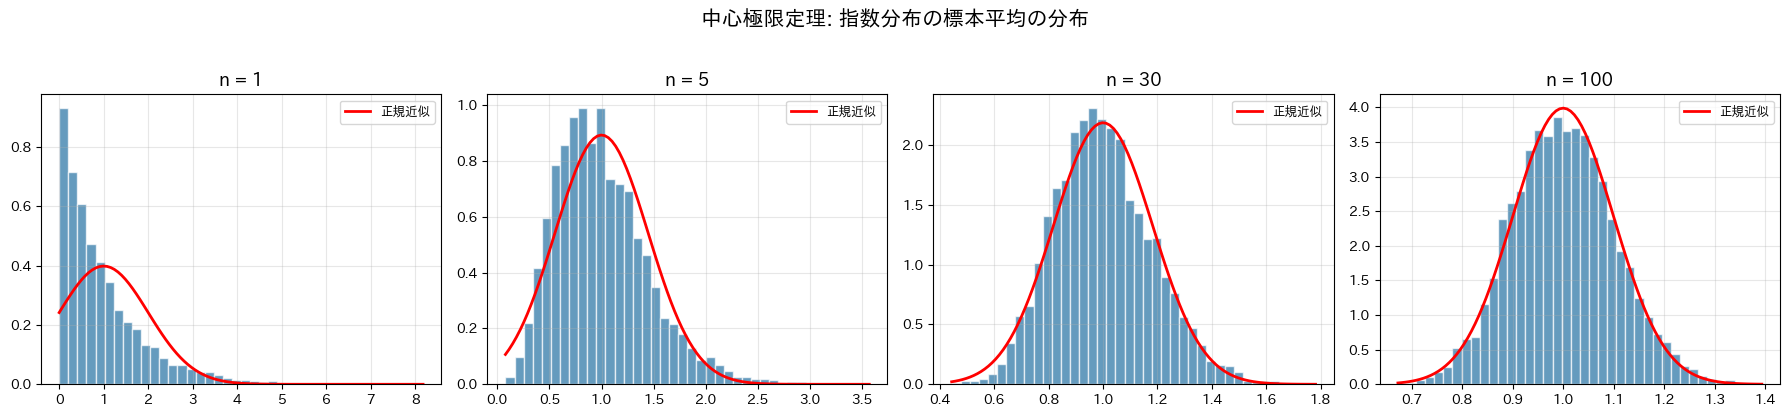

In [17]:
# 中心極限定理の実証
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 元の分布: 指数分布（明らかに非正規）
lam = 1.0
sample_sizes = [1, 5, 30, 100]

for ax, n in zip(axes, sample_sizes):
    means = [np.mean(np.random.exponential(1/lam, n)) for _ in range(5000)]
    ax.hist(means, bins=40, density=True, alpha=0.7, color='#2471A3', edgecolor='white')
    # 理論的な正規近似
    x_plot = np.linspace(min(means), max(means), 100)
    mu_theory = 1/lam
    sigma_theory = (1/lam) / np.sqrt(n)
    ax.plot(x_plot, stats.norm.pdf(x_plot, mu_theory, sigma_theory),
            'r-', linewidth=2, label='正規近似')
    ax.set_title(f'n = {n}', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('中心極限定理: 指数分布の標本平均の分布', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('clt_demonstration.png', dpi=150)
plt.show()


## 2つのモデルの交差検証スコア

In [18]:
from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_sc = StandardScaler().fit_transform(iris.data)
y = iris.target

# 2 つのモデルの交差検証スコア
model_a = LogisticRegression(max_iter=200, random_state=42)
model_b = DecisionTreeClassifier(max_depth=3, random_state=42)

scores_a = cross_val_score(model_a, X_sc, y, cv=10, scoring='accuracy')
scores_b = cross_val_score(model_b, X_sc, y, cv=10, scoring='accuracy')

# 対応のある t 検定
t_stat, p_value = stats.ttest_rel(scores_a, scores_b)

print("=== モデル比較（対応のある t 検定）===\n")
print(f"ロジスティック回帰: {scores_a.mean():.4f} ± {scores_a.std():.4f}")
print(f"決定木 (depth=3):  {scores_b.mean():.4f} ± {scores_b.std():.4f}")
print(f"\nt 統計量: {t_stat:.4f}")
print(f"p 値:     {p_value:.4f}")
if p_value < 0.05:
    print("→ 5% 有意水準で有意差あり")
else:
    print("→ 5% 有意水準で有意差なし")


=== モデル比較（対応のある t 検定）===

ロジスティック回帰: 0.9600 ± 0.0611
決定木 (depth=3):  0.9600 ± 0.0327

t 統計量: 0.0000
p 値:     1.0000
→ 5% 有意水準で有意差なし


## 信頼区間

In [19]:
k = len(scores_a)
mean_a = scores_a.mean()
se_a = scores_a.std() / np.sqrt(k)
t_crit = stats.t.ppf(0.975, df=k-1)

ci_lower = mean_a - t_crit * se_a
ci_upper = mean_a + t_crit * se_a

print(f"\nロジスティック回帰の 95% 信頼区間:")
print(f"  {ci_lower:.4f} $\le \mu \le$ {ci_upper:.4f}")



ロジスティック回帰の 95% 信頼区間:
  0.9163 $\le \mu \le$ 1.0037


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_855/4011622324.py:10: SyntaxWarning: invalid escape sequence '\l'
  print(f"  {ci_lower:.4f} $\le \mu \le$ {ci_upper:.4f}")


## ブートストラップ法

=== ブートストラップ法 ===

標本平均: 1.6919
95% 信頼区間（ブートストラップ）: [1.2227, 2.1963]


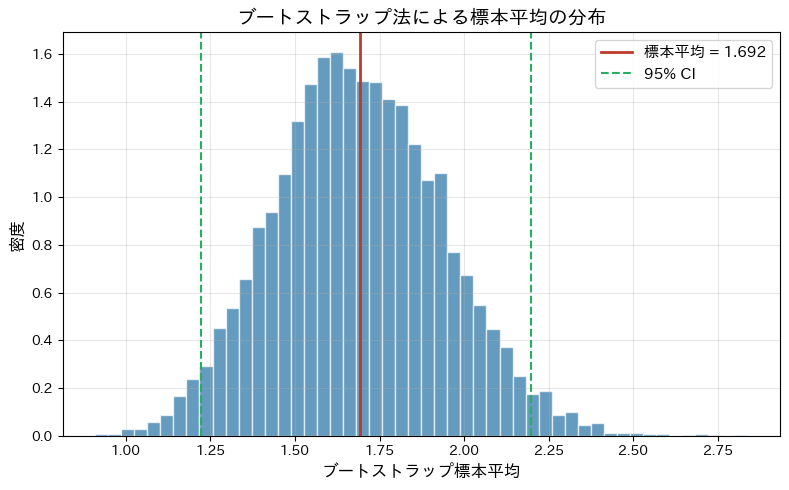

In [20]:
# ブートストラップ法で平均の信頼区間を推定
np.random.seed(42)
data = np.random.exponential(scale=2.0, size=50)

n_bootstrap = 10000
boot_means = np.array([
    np.mean(np.random.choice(data, size=len(data), replace=True))
    for _ in range(n_bootstrap)
])

ci_lower_boot = np.percentile(boot_means, 2.5)
ci_upper_boot = np.percentile(boot_means, 97.5)

print("=== ブートストラップ法 ===\n")
print(f"標本平均: {np.mean(data):.4f}")
print(f"95% 信頼区間（ブートストラップ）: [{ci_lower_boot:.4f}, {ci_upper_boot:.4f}]")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(boot_means, bins=50, density=True, alpha=0.7, color='#2471A3', edgecolor='white')
ax.axvline(x=np.mean(data), color='#C0392B', linewidth=2, label=f'標本平均 = {np.mean(data):.3f}')
ax.axvline(x=ci_lower_boot, color='#27AE60', linestyle='--', linewidth=1.5, label=f'95% CI')
ax.axvline(x=ci_upper_boot, color='#27AE60', linestyle='--', linewidth=1.5)
ax.set_xlabel('ブートストラップ標本平均', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title('ブートストラップ法による標本平均の分布', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bootstrap.png', dpi=150)
plt.show()
